In [213]:
# import pandas as pd
import matplotlib.pyplot as plt
import polars as pl

In [ ]:
def value_count(df: pl.DataFrame, value: str) -> None:
    return df.group_by(value).len().sort("len", descending=True)

In [ ]:
data_train = pl.read_csv("../datasets/raw/train.csv")
data_test = pl.read_csv("../datasets/raw/test.csv")

test_passenger_id = data_test.get_column("PassengerId")
drop_col = ["PassengerId", "Ticket", "Cabin"]

data_train = data_train.drop(drop_col)
data_test = data_test.drop(drop_col)

all_datasets = [data_train, data_test]
print(data_train.columns)

['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [ ]:
for dataset in all_datasets:
    
    print(dataset.shape)
    print(dataset.schema)

(891, 9)
Schema({'Survived': Int64, 'Pclass': Int64, 'Name': String, 'Sex': String, 'Age': Float64, 'SibSp': Int64, 'Parch': Int64, 'Fare': Float64, 'Embarked': String})
(418, 8)
Schema({'Pclass': Int64, 'Name': String, 'Sex': String, 'Age': Float64, 'SibSp': Int64, 'Parch': Int64, 'Fare': Float64, 'Embarked': String})


In [ ]:
for dataset in all_datasets:
    missing = dataset.select([
        pl.col(col).is_null().sum().alias(col)
        for col in dataset.columns
    ])
    print(missing)

shape: (1, 9)
┌──────────┬────────┬──────┬─────┬───┬───────┬───────┬──────┬──────────┐
│ Survived ┆ Pclass ┆ Name ┆ Sex ┆ … ┆ SibSp ┆ Parch ┆ Fare ┆ Embarked │
│ ---      ┆ ---    ┆ ---  ┆ --- ┆   ┆ ---   ┆ ---   ┆ ---  ┆ ---      │
│ u32      ┆ u32    ┆ u32  ┆ u32 ┆   ┆ u32   ┆ u32   ┆ u32  ┆ u32      │
╞══════════╪════════╪══════╪═════╪═══╪═══════╪═══════╪══════╪══════════╡
│ 0        ┆ 0      ┆ 0    ┆ 0   ┆ … ┆ 0     ┆ 0     ┆ 0    ┆ 2        │
└──────────┴────────┴──────┴─────┴───┴───────┴───────┴──────┴──────────┘
shape: (1, 8)
┌────────┬──────┬─────┬─────┬───────┬───────┬──────┬──────────┐
│ Pclass ┆ Name ┆ Sex ┆ Age ┆ SibSp ┆ Parch ┆ Fare ┆ Embarked │
│ ---    ┆ ---  ┆ --- ┆ --- ┆ ---   ┆ ---   ┆ ---  ┆ ---      │
│ u32    ┆ u32  ┆ u32 ┆ u32 ┆ u32   ┆ u32   ┆ u32  ┆ u32      │
╞════════╪══════╪═════╪═════╪═══════╪═══════╪══════╪══════════╡
│ 0      ┆ 0    ┆ 0   ┆ 86  ┆ 0     ┆ 0     ┆ 1    ┆ 0        │
└────────┴──────┴─────┴─────┴───────┴───────┴──────┴──────────┘


In [ ]:
age_median = data_train.select(pl.col("Age").median()).item()
fare_median = data_train.select(pl.col("Fare").median()).item()
# embarked_mode = data_train.select(pl.col("Embarked").mode()).item()
embarked_mode = (
    data_train
    .filter(pl.col("Embarked").is_not_null())
    .group_by("Embarked")
    .len()
    .sort("len", descending=True)
    .get_column("Embarked")[0]
)

all_datasets = []
for dataset in [data_train, data_test]:
    dataset = dataset.with_columns(
        pl.col("Age").fill_null(age_median),
        pl.col("Fare").fill_null(fare_median),
        pl.col("Embarked").fill_null(embarked_mode)
    )
    all_datasets.append(dataset)
    missing = dataset.select(
        pl.col(col).null_count()
        for col in dataset.columns
    )
    print(missing)

data_train, data_test = all_datasets

shape: (1, 9)
┌──────────┬────────┬──────┬─────┬───┬───────┬───────┬──────┬──────────┐
│ Survived ┆ Pclass ┆ Name ┆ Sex ┆ … ┆ SibSp ┆ Parch ┆ Fare ┆ Embarked │
│ ---      ┆ ---    ┆ ---  ┆ --- ┆   ┆ ---   ┆ ---   ┆ ---  ┆ ---      │
│ u32      ┆ u32    ┆ u32  ┆ u32 ┆   ┆ u32   ┆ u32   ┆ u32  ┆ u32      │
╞══════════╪════════╪══════╪═════╪═══╪═══════╪═══════╪══════╪══════════╡
│ 0        ┆ 0      ┆ 0    ┆ 0   ┆ … ┆ 0     ┆ 0     ┆ 0    ┆ 0        │
└──────────┴────────┴──────┴─────┴───┴───────┴───────┴──────┴──────────┘
shape: (1, 8)
┌────────┬──────┬─────┬─────┬───────┬───────┬──────┬──────────┐
│ Pclass ┆ Name ┆ Sex ┆ Age ┆ SibSp ┆ Parch ┆ Fare ┆ Embarked │
│ ---    ┆ ---  ┆ --- ┆ --- ┆ ---   ┆ ---   ┆ ---  ┆ ---      │
│ u32    ┆ u32  ┆ u32 ┆ u32 ┆ u32   ┆ u32   ┆ u32  ┆ u32      │
╞════════╪══════╪═════╪═════╪═══════╪═══════╪══════╪══════════╡
│ 0      ┆ 0    ┆ 0   ┆ 0   ┆ 0     ┆ 0     ┆ 0    ┆ 0        │
└────────┴──────┴─────┴─────┴───────┴───────┴──────┴──────────┘


In [ ]:

def add_features(
        df: pl.DataFrame,
        ) -> pl.DataFrame:
    return df.with_columns([
        (pl.col("SibSp") + pl.col("Parch") + 1).alias("FamilySize"),
        ((pl.col("SibSp") + pl.col("Parch") + 1) == 1).alias("IsSingle"),
        pl.col("Name").str.extract(r",\s*([^\.]+)\.", 1).alias("Title")
    ])

def filter_title(df:pl.DataFrame, title_threshold: int = 10) -> pl.DataFrame:
    title_count = value_count(data_train, "Title")
    common_titles = title_count.filter(pl.col("len") >= 10).get_column("Title").to_list()

    return df.with_columns(
        pl.when(pl.col("Title").is_in(common_titles))
        .then(pl.col("Title"))
        .otherwise(pl.lit("Misc"))
        .alias("Title")
    ).drop("Name")

data_train = add_features(data_train)
data_test = add_features(data_test)

data_train = filter_title(data_train)
data_test = filter_title(data_test)

In [ ]:
def get_quntile_breaks(
        df: pl.DataFrame,
        column: str,
        quantiles: tuple = (0.25, 0.5, 0.75),
        ) -> pl.DataFrame:
    
    breaks = []
    for q in quantiles:
        value = df.select(pl.col(column).quantile(q)).item()
        breaks.append(float(value))
    return breaks

def cut_into_quantiles(
        df: pl.DataFrame,
        column: str,
        breaks: list,
        ) -> pl.DataFrame:
    
    return df.with_columns(
        pl.col(column).cut(breaks).alias(f"{column}Bin")
    )

age_breaks = get_quntile_breaks(df=data_train, column="Age")
fare_breaks = get_quntile_breaks(df=data_train, column="Fare")

data_train = cut_into_quantiles(df=data_train, column="Age", breaks=age_breaks)
data_train = cut_into_quantiles(df=data_train, column="Fare", breaks=fare_breaks)

data_test = cut_into_quantiles(df=data_test, column="Age", breaks=age_breaks)
data_test = cut_into_quantiles(df=data_test, column="Fare", breaks=fare_breaks)

In [ ]:
print(data_train.sample(5))
print(data_train.schema)
print(data_test.sample(5))
print(data_test.schema)

shape: (5, 13)
┌──────────┬────────┬────────┬──────┬───┬──────────┬───────┬────────────┬───────────────┐
│ Survived ┆ Pclass ┆ Sex    ┆ Age  ┆ … ┆ IsSingle ┆ Title ┆ AgeBin     ┆ FareBin       │
│ ---      ┆ ---    ┆ ---    ┆ ---  ┆   ┆ ---      ┆ ---   ┆ ---        ┆ ---           │
│ i64      ┆ i64    ┆ str    ┆ f64  ┆   ┆ bool     ┆ str   ┆ enum       ┆ enum          │
╞══════════╪════════╪════════╪══════╪═══╪══════════╪═══════╪════════════╪═══════════════╡
│ 1        ┆ 1      ┆ female ┆ 49.0 ┆ … ┆ false    ┆ Mrs   ┆ (35, inf]  ┆ (31, inf]     │
│ 0        ┆ 3      ┆ male   ┆ 28.0 ┆ … ┆ true     ┆ Mr    ┆ (22, 28]   ┆ (-inf, 7.925] │
│ 0        ┆ 3      ┆ male   ┆ 28.0 ┆ … ┆ true     ┆ Mr    ┆ (22, 28]   ┆ (-inf, 7.925] │
│ 0        ┆ 3      ┆ male   ┆ 21.0 ┆ … ┆ true     ┆ Mr    ┆ (-inf, 22] ┆ (-inf, 7.925] │
│ 0        ┆ 3      ┆ male   ┆ 28.0 ┆ … ┆ true     ┆ Mr    ┆ (22, 28]   ┆ (-inf, 7.925] │
└──────────┴────────┴────────┴──────┴───┴──────────┴───────┴────────────┴────────────

In [ ]:
def add_code_columns_from_train(
        df: pl.DataFrame,
        column: str,
        ) -> pl.DataFrame:
    
    categories = data_train.select(pl.col(column).unique().sort()).get_column(column).to_list()
    mapping = {category: idx for idx, category in enumerate(categories)}

    return df.with_columns(
        pl.col(column).cast(pl.Utf8).replace(mapping).cast(pl.Int64).alias(f"{column}Code")
    )

columns_to_code = [
    "Sex",
    "Embarked",
    "Title",
    "AgeBin", 
    "FareBin",
    "IsSingle",
    ]

for column in columns_to_code:
    data_train = add_code_columns_from_train(df=data_train, column=column)
    data_test = add_code_columns_from_train(df=data_test, column=column)

In [ ]:
data_test.sample(5)
# print(data_test.schema)

Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsSingle,Title,AgeBin,FareBin,SexCode,EmbarkedCode,TitleCode,AgeBinCode,FareBinCode,IsSingleCode
i64,str,f64,i64,i64,f64,str,i64,bool,str,enum,enum,i64,i64,i64,i64,i64,i64
3,"""female""",24.0,0,0,7.75,"""Q""",1,true,"""Miss""","""(22, 28]""","""(-inf, 7.925]""",0,1,2,1,0,1
3,"""female""",18.0,0,0,7.8792,"""Q""",1,true,"""Miss""","""(-inf, 22]""","""(-inf, 7.925]""",0,1,2,0,0,1
1,"""male""",28.0,0,0,26.55,"""S""",1,true,"""Mr""","""(22, 28]""","""(14.4542, 31]""",1,2,3,1,2,1
1,"""male""",28.0,0,0,26.55,"""S""",1,true,"""Mr""","""(22, 28]""","""(14.4542, 31]""",1,2,3,1,2,1
3,"""female""",45.0,0,0,7.225,"""C""",1,true,"""Mrs""","""(35, inf]""","""(-inf, 7.925]""",0,0,4,3,0,1


In [ ]:
target = "Survived"

features_original = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "EmbarkedCode",
    "FamilySize",
    "IsSingleCode",
    "SexCode",
    "TitleCode",
]

features_binned = [
    "Pclass",
    "SexCode",
    "AgeBinCode",
    "FareBinCode",
    "EmbarkedCode",
    "FamilySize",
    "IsSingleCode",
    "TitleCode",
]

X_train = data_train.select(features_original)
y_train = data_train.select(target)
X_test = data_test.select(features_original)

X_train.sample(5)

Pclass,Age,SibSp,Parch,Fare,EmbarkedCode,FamilySize,IsSingleCode,SexCode,TitleCode
i64,f64,i64,i64,f64,i64,i64,i64,i64,i64
1,54.0,0,1,77.2875,2,2,0,1,3
2,52.0,0,0,13.5,2,1,1,1,3
3,20.0,0,0,7.8542,2,1,1,1,3
3,28.0,2,0,21.6792,0,3,0,1,3
3,28.0,8,2,69.55,2,11,0,0,2


In [ ]:
from pathlib import Path

original_train_dataset = data_train.select(features_original + [target])
binned_train_dataset = data_train.select(features_binned + [target])

original_test_dataset = data_test.select([test_passenger_id] + features_original)
binned_test_dataset = data_test.select([test_passenger_id] + features_binned)

Path("../datasets/processed/original").mkdir(parents=True, exist_ok=True)
Path("../datasets/processed/binned").mkdir(parents=True, exist_ok=True)

original_train_dataset.write_parquet("../datasets/processed/original/original_train_dataset.parquet")
original_train_dataset.write_csv("../datasets/processed/original/original_train_dataset.csv")

binned_train_dataset.write_parquet("../datasets/processed/binned/binned_train_dataset.parquet")
binned_train_dataset.write_csv("../datasets/processed/binned/binned_train_dataset.csv")

original_test_dataset.write_parquet("../datasets/processed/original/original_test_dataset.parquet")
original_test_dataset.write_csv("../datasets/processed/original/original_test_dataset.csv")

binned_test_dataset.write_parquet("../datasets/processed/binned/binned_test_dataset.parquet")
binned_test_dataset.write_csv("../datasets/processed/binned/binned_test_dataset.csv")


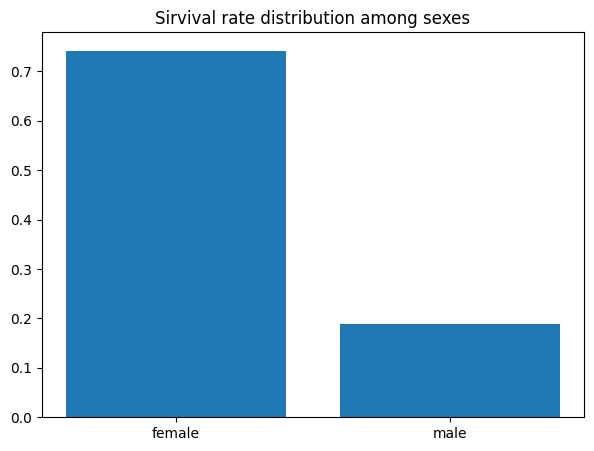

In [ ]:
survival_by_sex = (
    data_train
    .group_by("Sex")
    .agg(pl.col("Survived").mean().alias("survival_rate"))
    .sort("Sex")
    )

plt.figure(figsize=(7, 5))
plt.bar(
    survival_by_sex.get_column("Sex"),
    survival_by_sex.get_column("survival_rate"),
)
plt.title(label="Sirvival rate distribution among sexes")
plt.show()

In [224]:
numeric_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "SexCode",
    "EmbarkedCode",
    "TitleCode",
    "IsSingleCode",
]

corr_with_target = pl.DataFrame({
    "feature": numeric_columns,
    "corr_with_survived": [
        data_train.select(pl.corr(col, "Survived")).item()
        for col in numeric_columns
    ],
}).sort("corr_with_survived", descending=True)

corr_with_target


feature,corr_with_survived
str,f64
"""Survived""",1.0
"""Fare""",0.257307
"""Parch""",0.081629
"""FamilySize""",0.016639
"""SibSp""",-0.035322
…,…
"""TitleCode""",-0.083292
"""EmbarkedCode""",-0.167675
"""IsSingleCode""",-0.203367


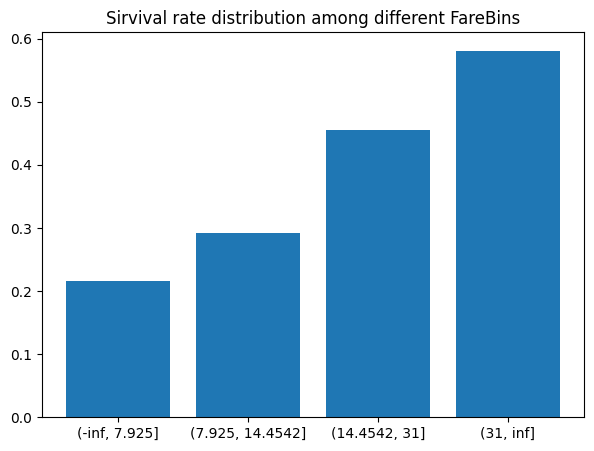

In [ ]:
survival_by_sex = (
    data_train
    .group_by("FareBin")
    .agg(pl.col("Survived").mean().alias("survival_rate"))
    .sort("FareBin")
    )

plt.figure(figsize=(7, 5))
plt.bar(
    survival_by_sex.get_column("FareBin"),
    survival_by_sex.get_column("survival_rate"),
)
plt.title(label="Sirvival rate distribution among different FareBins")
plt.show()